In [1]:
from pathlib import Path
from functools import namedtuple

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, kendalltau

sns.set_context("paper")
import tqdm.auto as tqdm

from dti import data
from dti.data import split_kfold_by
from dti.utils import scaffold_split
from dti.constants import ACT, ASSAY

In [2]:
data_path = Path("..") / "data" / "raw"
Row = namedtuple("Row", ["overlap", "correlation", "kendall"])

# Assay overlap in scaffold splits

In [3]:
def sample_assay_overlap(
    df: pd.DataFrame, seed: int, fillna: bool = False, progress: bool = False
):
    df_train, df_test = scaffold_split(df, seed=seed, progress=progress)
    overlap = df_test[ASSAY].isin(df_train[ASSAY]).mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )
    if fillna:
        df_test.fillna(value=df_train[ACT].mean(), inplace=True)
    corr = df_test.corr(numeric_only=True).loc["assay_mean", "activity_value"]
    kendall = kendalltau(
        df_test["assay_mean"].values, df_test["activity_value"].values
    ).statistic
    return overlap, corr, kendall

## ChEMBL

In [4]:
df = data.load_kinodata(data_path / "activities.csv")

In [5]:
dcorr1 = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/6896 [00:00<?, ?it/s]

significance   1.59e-72


overlap        0.803008
correlation    0.614113
kendall        0.295448
dtype: float64

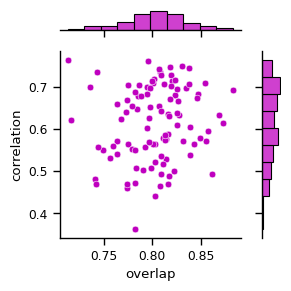

In [6]:
sns.jointplot(
    dcorr1,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/kinodata_scaffold_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr1["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr1.mean()

In [7]:
df = data.load_landrum(data_path / "omnivore.csv")
dcorr2 = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100))
    ]
)

  0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/838155 [00:00<?, ?it/s]

significance   1.32e-167


overlap        0.932732
correlation    0.734970
kendall        0.544847
dtype: float64

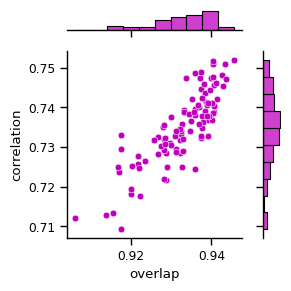

In [8]:
sns.jointplot(
    dcorr2,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/omnivore_scaffold_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr2["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr2.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

scaffold:   0%|          | 0/259823 [00:00<?, ?it/s]

significance   1.27e-170


overlap        0.972448
correlation    0.730687
kendall        0.534696
dtype: float64

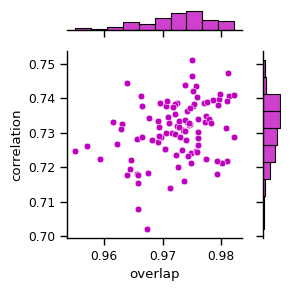

In [9]:
df = data.load_landrum(data_path / "landrum.csv")
dcorr3 = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed, fillna=True, progress=seed == 0))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr3,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/landrum_scaffold_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr3["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr3.mean()

# Assay overlap in random splits

In [14]:
def sample_assay_overlap_random(df: pd.DataFrame, seed: int, fillna: bool = False):
    np.random.seed(seed)
    df["train"] = np.random.rand(len(df)) > 0.2
    df_train, df_test = df[df["train"]], df[~df["train"]]
    overlap = df_test[ASSAY].isin(df_train[ASSAY]).mean()
    predictor = df_train.groupby(ASSAY)[[ACT]].agg("mean")
    df_test = df_test.join(
        predictor.rename(columns={ACT: "assay_mean"}), on=ASSAY, how="left"
    )
    if fillna:
        df_test.fillna(value=df_train[ACT].mean(), inplace=True)
    corr = df_test.corr(numeric_only=True).loc["assay_mean", "activity_value"]
    kendall = kendalltau(
        df_test["assay_mean"].values, df_test["activity_value"].values
    ).statistic

    return overlap, corr, kendall

## ChEMBL

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

overlap        0.947272
correlation    0.637191
kendall        0.409694
dtype: float64

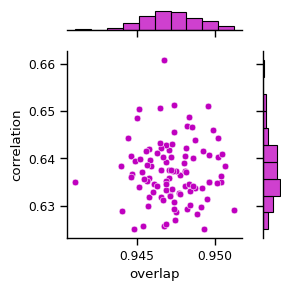

In [16]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")
dcorr4 = pd.DataFrame(
    [
        Row(*sample_assay_overlap_random(df, seed, fillna=True))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)
sns.jointplot(
    dcorr4,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/kinodata_scaffold_assay_overlap_random.pdf")
dcorr4.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

overlap        0.994539
correlation    0.813513
kendall        0.624778
dtype: float64

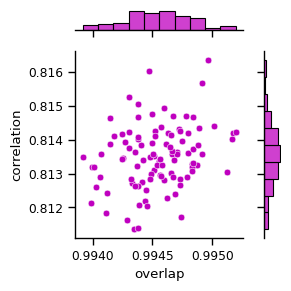

In [17]:
df = data.load_landrum(data_path / "omnivore.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap_random(df, seed, fillna=True))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/omnivore_scaffold_assay_overlap_random.pdf")
dcorr.mean()

  0%|          | 0/100 [00:00<?, ?it/s]

overlap        1.000000
correlation    0.805614
kendall        0.609440
dtype: float64

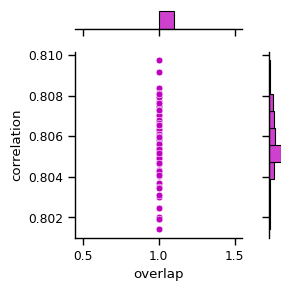

In [18]:
df = data.load_landrum(data_path / "landrum.csv")
dcorr = pd.DataFrame(
    [
        Row(*sample_assay_overlap_random(df, seed, fillna=True))
        for seed in tqdm.tqdm(range(100))
    ]
)
sns.jointplot(
    dcorr,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/landrum_scaffold_assay_overlap_random.pdf")
dcorr.mean()

# UMAP

In [19]:
ld_umap = pd.read_csv("../data/kinodata_umap.csv", index_col=0)
ld_umap.head()

,activities.activity_id,assays.chembl_id,target_dictionary.chembl_id,molecule_dictionary.chembl_id,molecule_dictionary.max_phase,activities.standard_type,activity_value,activities.standard_units,smiles,compound_structures.standard_inchi,...,assays.confidence_score,docs.chembl_id,docs.year,docs.authors,target,assay_id,compound_id,umap_1,umap_2,cluster
96698,16291323,CHEMBL3705523,CHEMBL2973,CHEMBL3666724,NaN,pIC50,14.096910,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C31H33N7O3/c1-2-4-29(40)33-22-6-3-5-2...,...,9,CHEMBL3639077,2014.0,NaN,O75116,3705523,3666724,5.137550,-0.554581,1
94326,16264754,CHEMBL3705523,CHEMBL2973,CHEMBL3666728,NaN,pIC50,14.000000,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C34H40N8O3/c1-5-7-32(43)36-24-9-6-8-2...,...,9,CHEMBL3639077,2014.0,NaN,O75116,3705523,3666728,5.119913,-0.612328,1
98119,16306943,CHEMBL3705523,CHEMBL2973,CHEMBL1968705,NaN,pIC50,14.000000,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C31H33N7O2/c1-2-6-29(39)33-23-8-5-7-2...,...,9,CHEMBL3639077,2014.0,NaN,O75116,3705523,1968705,5.139787,-0.539873,1
101161,16340050,CHEMBL3705523,CHEMBL2973,CHEMBL1997433,NaN,pIC50,13.958607,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C28H28N6O3/c1-3-5-26(35)30-20-7-4-6-1...,...,9,CHEMBL3639077,2014.0,NaN,O75116,3705523,1997433,8.427530,-2.876326,0
101541,16344107,CHEMBL3705523,CHEMBL2973,CHEMBL3666722,NaN,pIC50,13.920819,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C32H36N8O2/c1-3-5-30(41)34-24-7-4-6-2...,...,9,CHEMBL3639077,2014.0,NaN,O75116,3705523,3666722,5.131407,-0.536195,1


In [20]:
ld_umap.cluster.value_counts()

cluster
0    82601
1    35688
2    30645
3    22083
4     8965
Name: count, dtype: int64

In [21]:
rows = list()
for test_cluster in range(0, 5):
    ld_umap_train = ld_umap[ld_umap["cluster"] != test_cluster]
    ld_umap_test = ld_umap[ld_umap["cluster"] == test_cluster]

    assay_mean = (
        ld_umap_train.groupby("assay_id")
        .agg("mean", numeric_only=True)[["activity_value"]]
        .rename(columns={"activity_value": "prediction"})
        .reset_index()
    )
    ld_umap_test = ld_umap_test.merge(assay_mean, on="assay_id", how="left")
    print("train", len(ld_umap_train), "test", len(ld_umap_test))
    overlap = len(set(ld_umap_test["assay_id"]) & set(ld_umap_test["assay_id"])) / len(
        set(ld_umap["assay_id"])
    )

    ld_umap_test.fillna(ld_umap_train["activity_value"].mean(), inplace=True)

    corr = ld_umap_test.corr(numeric_only=True).loc["prediction", "activity_value"]
    rows.append(Row(overlap, corr))
dcorr1 = pd.DataFrame(rows)

train 97381 test 82601


TypeError: Row.__new__() missing 1 required positional argument: 'kendall'

In [ ]:
sns.jointplot(
    dcorr1,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/kinodata_umap_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr1["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr1.mean()

In [ ]:
ld_umap = pd.read_csv("../data/landrum_umap.csv", index_col=0)
ld_umap.head()

In [ ]:
ld_umap.cluster.value_counts()

In [ ]:
rows = list()
for test_cluster in range(0, 5):
    ld_umap_train = ld_umap[ld_umap["cluster"] != test_cluster]
    ld_umap_test = ld_umap[ld_umap["cluster"] == test_cluster]

    assay_mean = (
        ld_umap_train.groupby("assay_id")
        .agg("mean", numeric_only=True)[["activity_value"]]
        .rename(columns={"activity_value": "prediction"})
        .reset_index()
    )
    ld_umap_test = ld_umap_test.merge(assay_mean, on="assay_id", how="left")
    print("train", len(ld_umap_train), "test", len(ld_umap_test))
    overlap = len(set(ld_umap_test["assay_id"]) & set(ld_umap_test["assay_id"])) / len(
        set(ld_umap["assay_id"])
    )

    ld_umap_test.fillna(ld_umap_train["activity_value"].mean(), inplace=True)

    corr = ld_umap_test.corr(numeric_only=True).loc["prediction", "activity_value"]
    rows.append(Row(overlap, corr))
dcorr1 = pd.DataFrame(rows)

In [ ]:
sns.jointplot(
    dcorr1,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/landrum_umap_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr1["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr1.mean()

# Butina

In [22]:
def sample_assay_overlap(df, seed):
    parts = split_kfold_by(df, 5, "cluster", seed=seed)

    df_test = df[df["cluster"].isin(parts[0])]
    df_train = df[~df["cluster"].isin(parts[0])]
    assay_mean = (
        df_train.groupby("assay_id")
        .agg("mean", numeric_only=True)[["activity_value"]]
        .rename(columns={"activity_value": "prediction"})
        .reset_index()
    )
    df_test = df_test.merge(assay_mean, on="assay_id", how="left")
    overlap = len(set(df_test["assay_id"]) & set(df_test["assay_id"])) / len(
        set(df["assay_id"])
    )

    df_test.fillna(df_train["activity_value"].mean(), inplace=True)

    corr = df_test.corr(numeric_only=True).loc["prediction", "activity_value"]
    kendall = df_test.corr(numeric_only=True, method="kendall").loc[
        "prediction", "activity_value"
    ]
    return Row(overlap, corr, kendall)

## kinodata

In [23]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv.bkp")
clusters = pd.read_csv(data_path / ".." / "butina" / "kinodata" / "clusters.csv")
df = df.merge(clusters, left_on="smiles", right_on="SMILES")

In [24]:
dcorr1 = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

significance   5.03e-188


overlap        0.448082
correlation    0.748219
kendall        0.545778
dtype: float64

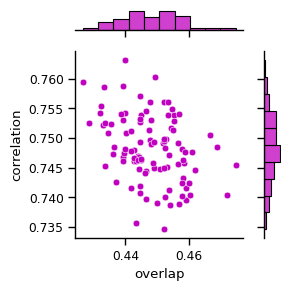

In [25]:
sns.jointplot(
    dcorr1,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/kinodata_butina_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr1["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr1.mean()

## landrum

In [26]:
df = data.load_landrum(data_path / "landrum.csv")
clusters = pd.read_csv(data_path / ".." / "butina" / "landrum" / "clusters.csv")
df = df.merge(clusters, left_on="smiles", right_on="SMILES")

In [27]:
dcorr1 = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

significance   5.52e-195


overlap        0.903928
correlation    0.776104
kendall        0.579261
dtype: float64

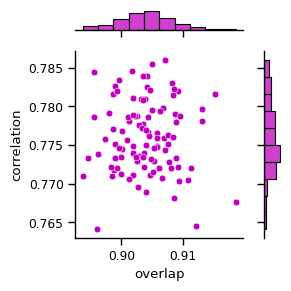

In [28]:
sns.jointplot(
    dcorr1,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/landrum_butina_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr1["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr1.mean()

## omnivore

In [29]:
df = data.load_landrum(data_path / "omnivore.csv")
clusters = pd.read_csv(data_path / ".." / "butina" / "omnivore" / "clusters.csv")
df = df.merge(clusters, left_on="smiles", right_on="SMILES")

In [30]:
dcorr1 = pd.DataFrame(
    [
        Row(*sample_assay_overlap(df, seed))
        for seed in tqdm.tqdm(range(100), desc="sample overlap")
    ]
)

sample overlap:   0%|          | 0/100 [00:00<?, ?it/s]

significance   1.14e-200


overlap        0.640336
correlation    0.779015
kendall        0.589387
dtype: float64

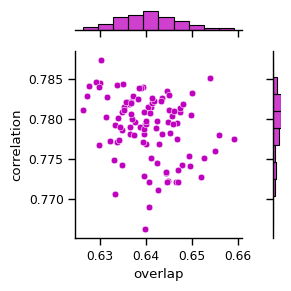

In [31]:
sns.jointplot(
    dcorr1,
    x="overlap",
    y="correlation",
    kind="scatter",
    color="m",
    marginal_ticks=False,
    marginal_kws=dict(bins=10),
    height=3,
)
plt.tight_layout()
plt.savefig("img/omnivore_butina_assay_overlap.pdf")
significance = ttest_1samp(np.atanh(dcorr1["correlation"].values), 0).pvalue
print(f"significance   {significance:.2e}")
dcorr1.mean()